**EDA PROJECT**

**Loan Approval Analytics using Python.**

**1. Business Understanding:**

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
df = pd.read_csv('loan_sanction_train.csv')
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


**2. Dataset Understanding:**

In [7]:
print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
print('\nData types:')
display(df.dtypes.to_frame('dtype'))
print('\nSummary statistics:')
display(df.describe(include='all').T)

Shape: (614, 13)

Columns: ['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']

Data types:


,dtype
Loan_ID,object
Gender,object
Married,object
Dependents,object
Education,object
Self_Employed,object
ApplicantIncome,int64
CoapplicantIncome,float64
LoanAmount,float64
Loan_Amount_Term,float64



Summary statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Loan_ID,614,614,LP001002,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,601,2,Male,489,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Married,611,2,Yes,398,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,599,4,0,345,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education,614,2,Graduate,480,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Self_Employed,582,2,No,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ApplicantIncome,614.0,NaN,NaN,NaN,5403.459283,6109.041673,150.0,2877.5,3812.5,5795.0,81000.0
CoapplicantIncome,614.0,NaN,NaN,NaN,1621.245798,2926.248369,0.0,0.0,1188.5,2297.25,41667.0
LoanAmount,592.0,NaN,NaN,NaN,146.412162,85.587325,9.0,100.0,128.0,168.0,700.0
Loan_Amount_Term,600.0,NaN,NaN,NaN,342.0,65.12041,12.0,360.0,360.0,360.0,480.0


**3. Data Quality Assessment:**

In [8]:
missing = pd.DataFrame({
    'Missing_Count': df.isna().sum(),
    'Missing_Percent': (df.isna().mean()*100).round(2)
}).query('Missing_Count > 0').sort_values('Missing_Count', ascending=False)
display(missing)

print('Duplicate rows:', df.duplicated().sum())
for col in ['Gender','Married','Dependents','Education','Self_Employed','Property_Area','Loan_Status']:
    print(col, sorted(df[col].dropna().astype(str).unique()))

,Missing_Count,Missing_Percent
Credit_History,50,8.14
Self_Employed,32,5.21
LoanAmount,22,3.58
Dependents,15,2.44
Loan_Amount_Term,14,2.28
Gender,13,2.12
Married,3,0.49


Duplicate rows: 0
Gender ['Female', 'Male']
Married ['No', 'Yes']
Dependents ['0', '1', '2', '3+']
Education ['Graduate', 'Not Graduate']
Self_Employed ['No', 'Yes']
Property_Area ['Rural', 'Semiurban', 'Urban']
Loan_Status ['N', 'Y']


Cleaning decisions
- No duplicate rows are removed because the duplicate check found none.
- Missing categorical values are filled with the mode.
- Missing numerical values are filled with the median because income/loan variables are skewed and the median is less sensitive to extreme values.
- `Dependents` is standardized from `3+` to numeric `3` for analysis.
- No raw records are manually edited.
- Outliers are retained because extreme income/loan values can be legitimate applicant observations; the brief requires a justified retain/remove/transform decision.

In [9]:
clean_df = df.copy()
for col in ['Gender','Married','Dependents','Self_Employed']:
    clean_df[col] = clean_df[col].fillna(clean_df[col].mode()[0])
for col in ['LoanAmount','Loan_Amount_Term','Credit_History']:
    clean_df[col] = clean_df[col].fillna(clean_df[col].median())
clean_df['Dependents'] = clean_df['Dependents'].replace('3+', '3').astype(int)
print('Missing after cleaning:')
display(clean_df.isna().sum().to_frame('Missing'))
print('Duplicates after cleaning:', clean_df.duplicated().sum())

Missing after cleaning:


,Missing
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


Duplicates after cleaning: 0


**4. Outlier Analysis:**

,Feature,Q1,Q3,Lower_Bound,Upper_Bound,Outlier_Count
0,ApplicantIncome,2877.50,5795.00,-1498.750,10171.250,50
1,CoapplicantIncome,0.00,2297.25,-3445.875,5743.125,18
2,LoanAmount,100.25,164.75,3.500,261.500,41
3,Loan_Amount_Term,360.00,360.00,360.000,360.000,88


C:\Users\UDAY KUMAR\AppData\Local\Temp\ipykernel_30300\2618749882.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([clean_df[c].dropna() for c in num_cols], labels=num_cols)


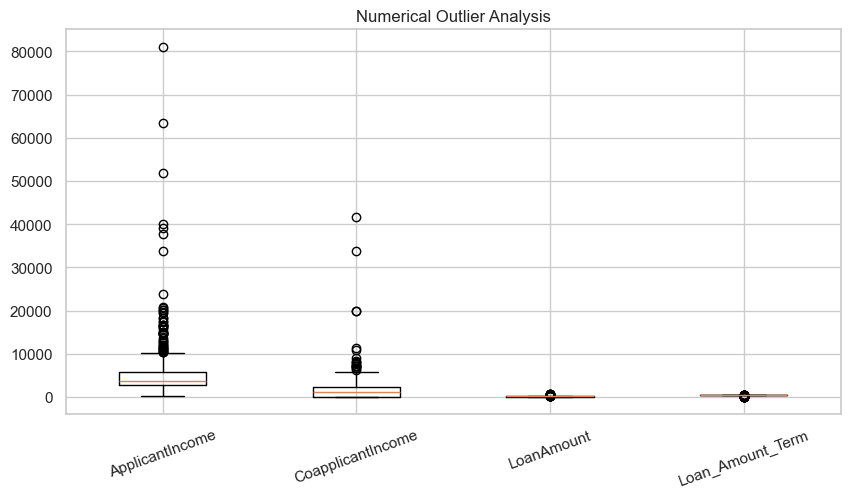

In [10]:
num_cols = ['ApplicantIncome','CoapplicantIncome','LoanAmount','Loan_Amount_Term']
out = []
for col in num_cols:
    q1, q3 = clean_df[col].quantile([.25,.75])
    iqr = q3-q1
    lo, hi = q1-1.5*iqr, q3+1.5*iqr
    n = ((clean_df[col]<lo)|(clean_df[col]>hi)).sum()
    out.append([col,q1,q3,lo,hi,n])
display(pd.DataFrame(out, columns=['Feature','Q1','Q3','Lower_Bound','Upper_Bound','Outlier_Count']))

fig, ax = plt.subplots(figsize=(10,5))
ax.boxplot([clean_df[c].dropna() for c in num_cols], labels=num_cols)
ax.set_title('Numerical Outlier Analysis')
ax.tick_params(axis='x', rotation=20)
plt.show()

**5. Descriptive Analysis:**

In [11]:
desc = clean_df[num_cols + ['Credit_History']].describe().T
desc['variance'] = clean_df[num_cols + ['Credit_History']].var()
desc['skewness'] = clean_df[num_cols + ['Credit_History']].skew()
display(desc)

,count,mean,std,min,25%,50%,75%,max,variance,skewness
ApplicantIncome,614.0,5403.459283,6109.041673,150.0,2877.50,3812.5,5795.00,81000.0,3.732039e+07,6.539513
CoapplicantIncome,614.0,1621.245798,2926.248369,0.0,0.00,1188.5,2297.25,41667.0,8.562930e+06,7.491531
LoanAmount,614.0,145.752443,84.107233,9.0,100.25,128.0,164.75,700.0,7.074027e+03,2.743053
Loan_Amount_Term,614.0,342.410423,64.428629,12.0,360.00,360.0,360.00,480.0,4.151048e+03,-2.402112
Credit_History,614.0,0.855049,0.352339,0.0,1.00,1.0,1.00,1.0,1.241425e-01,-2.021971


**6. Univariate Analysis:**

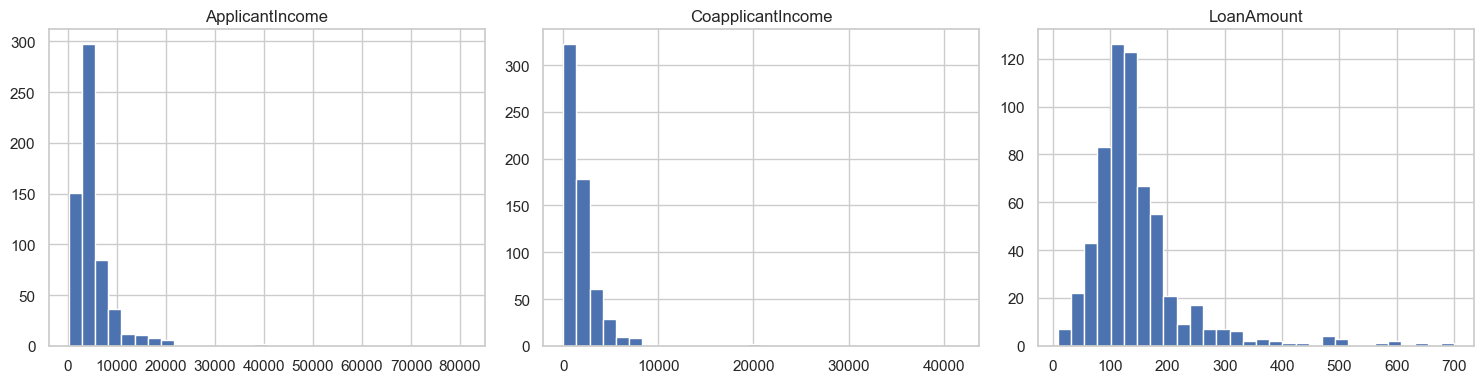

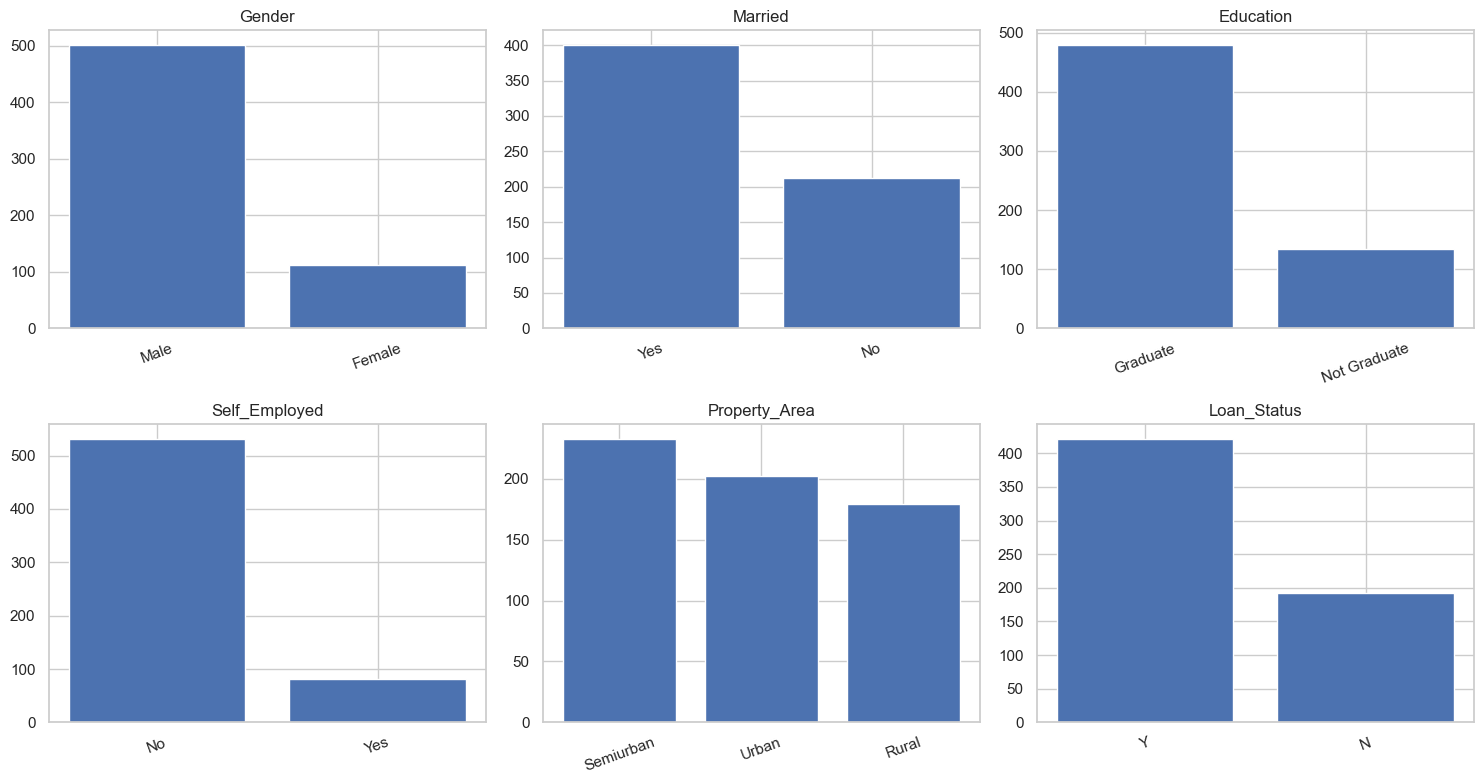

,Count
Loan_Status,
Y,422
N,192


,Percent
Loan_Status,
Y,68.73
N,31.27


In [12]:
fig, axes = plt.subplots(1,3,figsize=(15,4))
for ax,col in zip(axes,['ApplicantIncome','CoapplicantIncome','LoanAmount']):
    ax.hist(clean_df[col], bins=30)
    ax.set_title(col)
plt.tight_layout()
plt.show()

cat_cols=['Gender','Married','Education','Self_Employed','Property_Area','Loan_Status']
fig, axes=plt.subplots(2,3,figsize=(15,8))
for ax,col in zip(axes.ravel(),cat_cols):
    counts=clean_df[col].value_counts()
    ax.bar(counts.index.astype(str),counts.values)
    ax.set_title(col)
    ax.tick_params(axis='x',rotation=20)
plt.tight_layout()
plt.show()

display(clean_df['Loan_Status'].value_counts().to_frame('Count'))
display((clean_df['Loan_Status'].value_counts(normalize=True)*100).round(2).to_frame('Percent'))

**Observation:** 422 of 614 applications are approved (68.73%) and 192 are rejected (31.27%). Approval is therefore the majority class.

**7. Required Bivariate Analysis:**

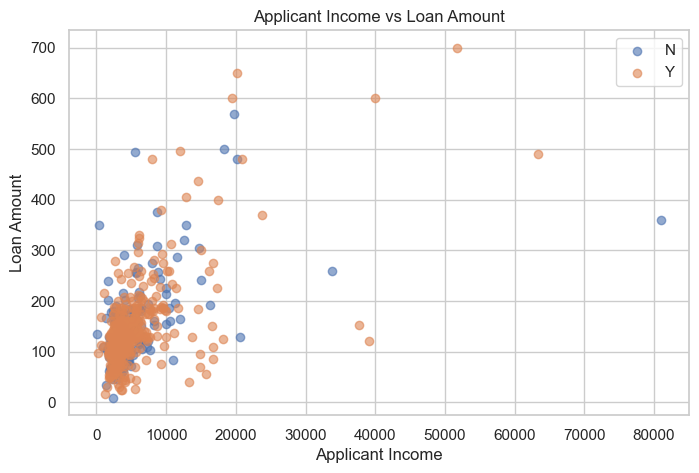


 Gender


,Approval_Rate_%
Gender,
Female,66.96
Male,69.12



 Married


,Approval_Rate_%
Married,
No,62.91
Yes,71.82



 Education


...

,Approval_Rate_%
Property_Area,
Rural,61.45
Semiurban,76.82
Urban,65.84



 Dependents


,Approval_Rate_%
Dependents,
0,68.61
1,64.71
2,75.25
3,64.71



 Credit_History


,Approval_Rate_%
Credit_History,
0.0,7.87
1.0,79.05


In [13]:
plt.figure(figsize=(8,5))
for status, grp in clean_df.groupby('Loan_Status'):
    plt.scatter(grp['ApplicantIncome'],grp['LoanAmount'],label=status,alpha=.6)
plt.xlabel('Applicant Income'); plt.ylabel('Loan Amount')
plt.title('Applicant Income vs Loan Amount'); plt.legend(); plt.show()

features=['Gender','Married','Education','Self_Employed','Property_Area','Dependents','Credit_History']
for col in features:
    rate=clean_df.groupby(col)['Loan_Status'].apply(lambda s:(s=='Y').mean()*100)
    print('\n',col)
    display(rate.round(2).to_frame('Approval_Rate_%'))

**Bivariate observations**
- Applicant income and loan amount have a moderate positive relationship, but with substantial variation.
- Credit history shows a very large difference in observed approval rates.
- Semiurban applicants have the highest observed approval rate among property-area groups.
- Married applicants and graduates show higher observed approval rates than their comparison groups.
- Male and female approval rates are relatively close.
- Self-employment shows little difference in approval rate in this dataset.
These are observed associations, not causal conclusions.

**8. Group-Based Analysis, Pivot Tables & Crosstabs:**

In [14]:
def approval_pivot(col):
    p=pd.crosstab(clean_df[col],clean_df['Loan_Status'])
    p['Total']=p.sum(axis=1)
    p['Approval_Rate_%']=p.get('Y',0)/p['Total']*100
    return p.round(2)

for col in ['Property_Area','Education','Credit_History','Married']:
    print('\nPivot:',col)
    display(approval_pivot(col))

print('Crosstab: Property Area x Loan Status')
display(pd.crosstab(clean_df['Property_Area'],clean_df['Loan_Status'],margins=True))


Pivot: Property_Area


Loan_Status,N,Y,Total,Approval_Rate_%
Property_Area,,,,
Rural,69,110,179,61.45
Semiurban,54,179,233,76.82
Urban,69,133,202,65.84



Pivot: Education


Loan_Status,N,Y,Total,Approval_Rate_%
Education,,,,
Graduate,140,340,480,70.83
Not Graduate,52,82,134,61.19



Pivot: Credit_History


Loan_Status,N,Y,Total,Approval_Rate_%
Credit_History,,,,
0.0,82,7,89,7.87
1.0,110,415,525,79.05



Pivot: Married


Loan_Status,N,Y,Total,Approval_Rate_%
Married,,,,
No,79,134,213,62.91
Yes,113,288,401,71.82


Crosstab: Property Area x Loan Status


Loan_Status,N,Y,All
Property_Area,,,
Rural,69,110,179
Semiurban,54,179,233
Urban,69,133,202
All,192,422,614


**9. Multivariate Analysis**

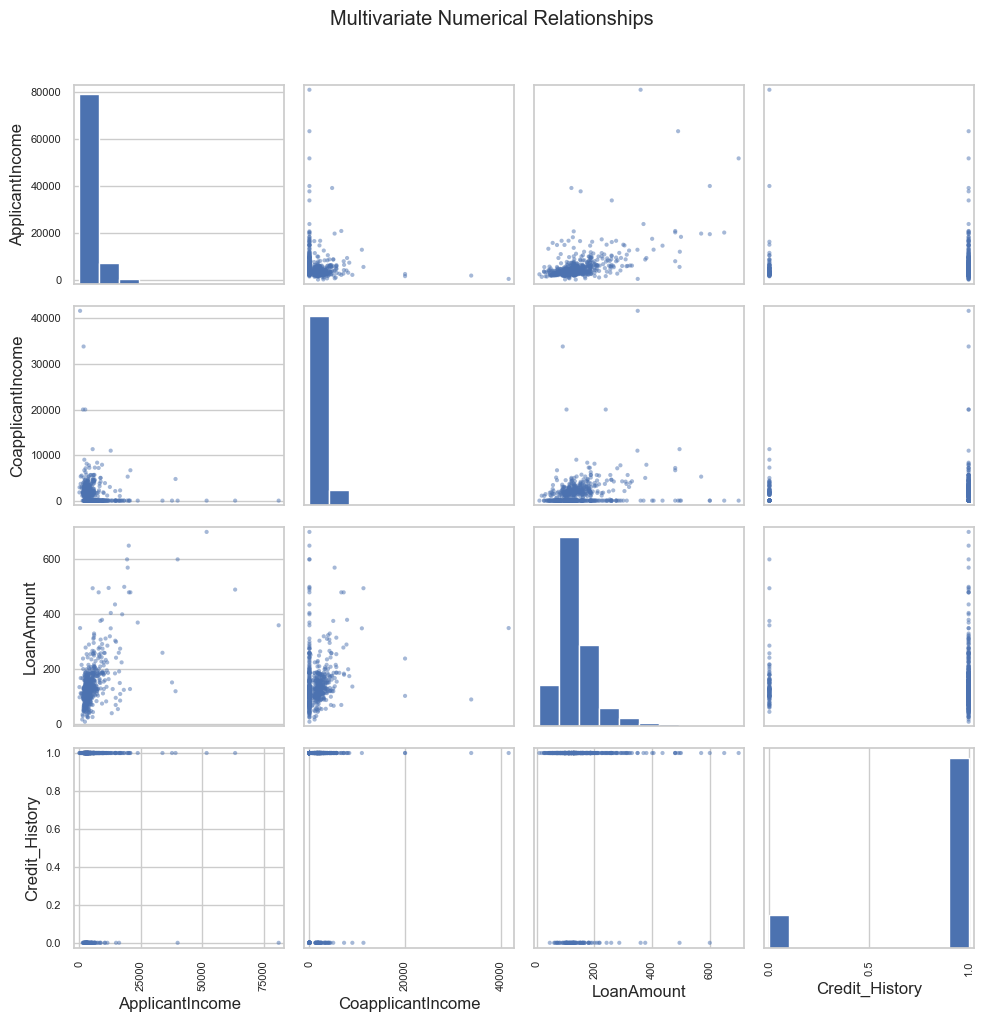

In [15]:
pd.plotting.scatter_matrix(
    clean_df[['ApplicantIncome','CoapplicantIncome','LoanAmount','Credit_History']],
    figsize=(10,10), diagonal='hist'
)
plt.suptitle('Multivariate Numerical Relationships',y=1.02)
plt.tight_layout()
plt.show()

**10. Correlation Analysis:**

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Dependents
ApplicantIncome,1.000,-0.117,0.565,-0.047,-0.019,0.118
CoapplicantIncome,-0.117,1.000,0.189,-0.059,0.011,0.030
LoanAmount,0.565,0.189,1.000,0.037,-0.001,0.163
Loan_Amount_Term,-0.047,-0.059,0.037,1.000,-0.005,-0.104
Credit_History,-0.019,0.011,-0.001,-0.005,1.000,-0.040
Dependents,0.118,0.030,0.163,-0.104,-0.040,1.000


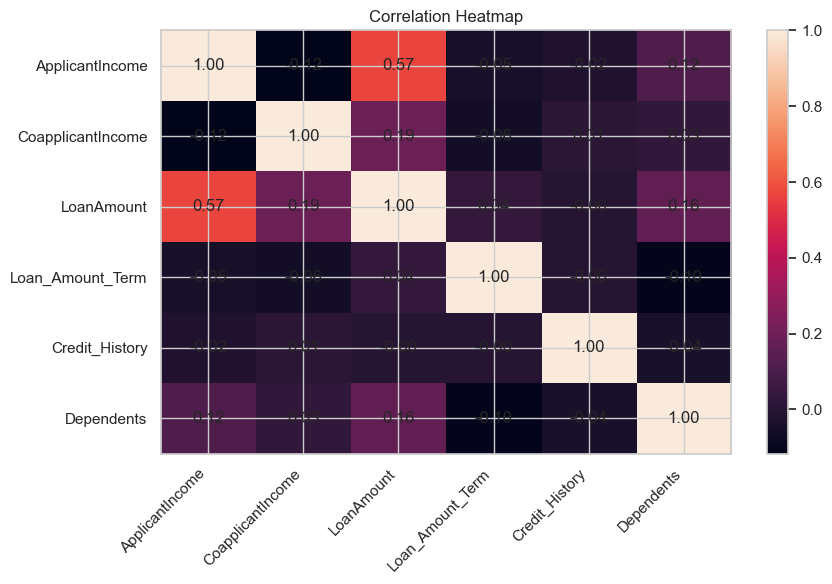

In [16]:
corr=clean_df[['ApplicantIncome','CoapplicantIncome','LoanAmount','Loan_Amount_Term','Credit_History','Dependents']].corr()
display(corr.round(3))
plt.figure(figsize=(9,6))
plt.imshow(corr,aspect='auto')
plt.colorbar()
plt.xticks(range(len(corr.columns)),corr.columns,rotation=45,ha='right')
plt.yticks(range(len(corr.index)),corr.index)
for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        plt.text(j,i,f'{corr.iloc[i,j]:.2f}',ha='center',va='center')
plt.title('Correlation Heatmap')
plt.tight_layout(); plt.show()

**Observation:** Applicant income and loan amount have a moderate positive correlation (about 0.565). The remaining numerical relationships are mostly weak. Correlation indicates association, not causation.

**11. Statistical Validation — Chi-Square:**

In [17]:
chi=[]
for col in features:
    tab=pd.crosstab(clean_df[col],clean_df['Loan_Status'])
    stat,p,dof,expected=stats.chi2_contingency(tab)
    chi.append([col,stat,p,dof,'Reject H0' if p<.05 else 'Fail to Reject H0'])
chi_results=pd.DataFrame(chi,columns=['Feature','Chi2','p_value','df','Decision'])
display(chi_results)

,Feature,Chi2,p_value,df,Decision
0,Gender,0.110879,7.391461e-01,1,Fail to Reject H0
1,Married,4.731876,2.960858e-02,1,Reject H0
2,Education,4.091490,4.309962e-02,1,Reject H0
3,Self_Employed,0.000000,1.000000e+00,1,Fail to Reject H0
4,Property_Area,12.297623,2.136019e-03,2,Reject H0
5,Dependents,3.151399,3.688663e-01,3,Fail to Reject H0
6,Credit_History,176.114575,3.418350e-40,1,Reject H0


**Interpretation:** At α=0.05, the sample shows statistical evidence of association for Married, Education, Property_Area and Credit_History. Gender, Self_Employed and Dependents do not show sufficient evidence of association at this threshold. Statistical significance does not establish causation.

**12. T-Test — Applicant Income:**

In [18]:
approved=clean_df.loc[clean_df.Loan_Status=='Y','ApplicantIncome']
rejected=clean_df.loc[clean_df.Loan_Status=='N','ApplicantIncome']
t,p=stats.ttest_ind(approved,rejected,equal_var=False)
print('Approved mean:',approved.mean())
print('Rejected mean:',rejected.mean())
print('t-statistic:',t)
print('p-value:',p)
print('Decision:', 'Reject H0' if p<.05 else 'Fail to Reject H0')

Approved mean: 5384.068720379147
Rejected mean: 5446.078125
t-statistic: -0.10944913176213944
p-value: 0.9129148547301199
Decision: Fail to Reject H0


**Interpretation:** The p-value is approximately 0.913, so there is not sufficient evidence at α=0.05 that mean applicant income differs between approved and rejected groups.

**13. Covariance & Confidence Interval:**

In [19]:
numeric=clean_df[['ApplicantIncome','CoapplicantIncome','LoanAmount','Loan_Amount_Term','Credit_History']]
display(numeric.cov())
x=clean_df['ApplicantIncome']
ci=stats.t.interval(.95,len(x)-1,loc=x.mean(),scale=stats.sem(x))
print('95% CI for mean ApplicantIncome:',ci)

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
ApplicantIncome,3.732039e+07,-2.084490e+06,290397.998060,-18314.518335,-40.068717
CoapplicantIncome,-2.084490e+06,8.562930e+06,46570.025909,-11195.741238,11.479406
LoanAmount,2.903980e+05,4.657003e+04,7074.026707,200.284477,-0.017998
Loan_Amount_Term,-1.831452e+04,-1.119574e+04,200.284477,4151.048244,-0.106806
Credit_History,-4.006872e+01,1.147941e+01,-0.017998,-0.106806,0.124142


95% CI for mean ApplicantIncome: (np.float64(4919.292129904242), np.float64(5887.626436871003))


**14. Feature Engineering:**

In [20]:
fe=clean_df.copy()
fe['Total_Household_Income']=fe['ApplicantIncome']+fe['CoapplicantIncome']

q1,q3=fe['Total_Household_Income'].quantile([.25,.75])
fe['Income_Category']=pd.cut(fe['Total_Household_Income'],[-np.inf,q1,q3,np.inf],labels=['Low','Medium','High'])

lq1,lq3=fe['LoanAmount'].quantile([.25,.75])
fe['Loan_Amount_Category']=pd.cut(fe['LoanAmount'],[-np.inf,lq1,lq3,np.inf],labels=['Low','Medium','High'])

fe['Income_to_Loan_Ratio']=fe['Total_Household_Income']/fe['LoanAmount'].replace(0,np.nan)
fe['Estimated_Monthly_EMI']=fe['LoanAmount']*1000/fe['Loan_Amount_Term'].replace(0,np.nan)
fe['EMI_Burden_Ratio']=fe['Estimated_Monthly_EMI']/fe['Total_Household_Income'].replace(0,np.nan)
fe['EMI_Burden_Category']=pd.cut(fe['EMI_Burden_Ratio'],[-np.inf,.05,.10,np.inf],labels=['Low','Medium','High'])

median_ratio=fe['Income_to_Loan_Ratio'].median()
fe['Applicant_Risk_Category']=np.select(
    [fe['Credit_History'].eq(0),(fe['Credit_History'].eq(1))&(fe['Income_to_Loan_Ratio']<median_ratio)],
    ['Higher Risk','Moderate Risk'],default='Lower Risk')

display(fe[['Total_Household_Income','Income_Category','Loan_Amount_Category','Income_to_Loan_Ratio','EMI_Burden_Category','Applicant_Risk_Category']].head())

,Total_Household_Income,Income_Category,Loan_Amount_Category,Income_to_Loan_Ratio,EMI_Burden_Category,Applicant_Risk_Category
0,5849.0,Medium,Medium,45.695312,Medium,Lower Risk
1,6091.0,Medium,Medium,47.585938,Medium,Lower Risk
2,3000.0,Low,Low,45.454545,Medium,Lower Risk
3,4941.0,Medium,Medium,41.175000,Medium,Moderate Risk
4,6000.0,Medium,Medium,42.553191,Medium,Lower Risk


**Feature purpose:**
- **Total_Household_Income:** combines applicant and co-applicant income.
- **Income_Category:** supports applicant segmentation.
- **Loan_Amount_Category:** supports loan-size segmentation.
- **Income_to_Loan_Ratio:** provides a relative capacity-to-request measure.
- **Estimated_Monthly_EMI / EMI_Burden_Ratio:** analytical burden proxies; the dataset has no interest rate, so this is not a bank-grade EMI calculation.
- **Applicant_Risk_Category:** simple profiling based on credit history and relative income-to-loan capacity; it is not a formal credit score.

In [21]:
for col in ['Income_Category','Loan_Amount_Category','EMI_Burden_Category','Applicant_Risk_Category']:
    print('\n',col)
    display(pd.crosstab(fe[col],fe['Loan_Status'],normalize='index').mul(100).round(2))


 Income_Category


Loan_Status,N,Y
Income_Category,,
Low,32.26,67.74
Medium,30.16,69.84
High,32.47,67.53



 Loan_Amount_Category


Loan_Status,N,Y
Loan_Amount_Category,,
Low,30.52,69.48
Medium,29.41,70.59
High,35.71,64.29



 EMI_Burden_Category


Loan_Status,N,Y
EMI_Burden_Category,,
Low,33.64,66.36
Medium,28.09,71.91
High,50.00,50.00



 Applicant_Risk_Category


Loan_Status,N,Y
Applicant_Risk_Category,,
Higher Risk,92.13,7.87
Lower Risk,22.93,77.07
Moderate Risk,18.92,81.08


**15. Final Business Insights & Recommendations:**
1. **Credit history:** applicants with credit history = 1 have a substantially higher observed approval rate than those with credit history = 0.
2. **Property area:** Semiurban applicants show the highest observed approval rate among the three property-area groups.
3. **Income alone:** the t-test does not show a statistically significant difference in mean applicant income between approval groups.
4. **Income and loan amount:** there is a moderate positive relationship, meaning larger requested loans tend to occur with higher applicant income.
5. **Class imbalance:** approvals are the majority outcome (422/614).
6. **Statistical associations:** Married, Education, Property_Area and Credit_History are statistically associated with Loan_Status at α=0.05 in this sample.

**Recommendations:** use credit history together with financial and applicant information; monitor approval patterns by property area; use household income and income-to-loan ratio for profiling; investigate high-income rejected applications for additional decision factors; and account for class imbalance in any future predictive model. The supplied brief asks for actionable recommendations aimed at better approval decisions, risk reduction and customer profiling.

**16. Submission Checklist:**
- Cleaned Dataset
- Sprint 1 Notebook
- Sprint 2 EDA / Visualization Notebook
- Sprint 3 Statistical / Feature Engineering Notebook
- Business Insights Report
- Statistical Analysis Report
These are the final deliverables listed in the supplied project brief.